# Portfolio Project: Predictive Lead Scoring & ROI Optimization

## Executive Summary
In high-volume sales environments like automotive digital retail, Sales Development Reps (SDRs) and Business Development Centers (BDCs) often waste significant time chasing unqualified leads. This project demonstrates a machine learning solution to optimize sales operations and reduce wasted labor costs.

## Objective
To build a **Predictive Lead Scoring Model** using **XGBoost** that evaluates customer digital behavior (e.g., time on configurator, trade-in valuations and financing applications) to predict the probability of conversion. Instead of treating all leads equally, this model empowers sales teams to prioritize outreach based on data-driven likelihoods.

## Methodology
1. **Data Simulation**: Generating a realistic, highly imbalanced dataset reflecting modern automotive CRM metrics.
2. **Machine Learning**: Training an XGBoost Classifier, the industry standard for tabular data and imbalanced target variables (where non-converters heavily outweigh converters).
3. **Business Translation**: Bridging the gap between standard ML metrics (Accuracy and ROC-AUC) and tangible business ROI by calculating saved labor costs and captured conversions.

Below is the complete, self-contained Python pipeline.

In [12]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# ==========================================
# PHASE 1: GENERATE SYNTHETIC DIGITAL RETAIL CRM DATA
# ==========================================
print("Generating synthetic digital retail CRM data...")
np.random.seed(42)
num_leads = 10000

# Simulating customer behavior on an automotive website
data = {
    'time_on_configurator_mins': np.random.gamma(shape=2, scale=4, size=num_leads),
    'vehicles_viewed_count': np.random.poisson(lam=3, size=num_leads) + 1,
    'trade_in_valued': np.random.choice([0, 1], size=num_leads, p=[0.65, 0.35]),
    'financing_app_started': np.random.choice([0, 1], size=num_leads, p=[0.80, 0.20]),
    'lead_source': np.random.choice(
        ['Organic Search', 'Paid Social', 'OEM Retargeting', 'Third-Party Aggregator'],
        size=num_leads, p=[0.3, 0.2, 0.3, 0.2]
    ),
    'credit_tier_estimated': np.random.choice(
        ['Tier 1', 'Tier 2', 'Tier 3', 'Unknown'],
        size=num_leads, p=[0.25, 0.35, 0.15, 0.25]
    )
}

df = pd.DataFrame(data)

# Creating a realistic target variable (Conversion) based on behavior
# Customers who value a trade-in and start financing are highly likely to convert
conversion_prob = (
    (df['time_on_configurator_mins'] * 0.02) +
    (df['vehicles_viewed_count'] * 0.01) +
    (df['trade_in_valued'] * 0.30) +
    (df['financing_app_started'] * 0.40)
)
# Normalize probabilities to a realistic conversion rate (~12% overall)
df['converted'] = (conversion_prob + np.random.normal(0, 0.1, num_leads) > 0.65).astype(int)

# ==========================================
# PHASE 2: DATA PREPROCESSING
# ==========================================
print("Preprocessing data and encoding categorical variables...")
# Convert categorical text data into numbers so the ML model can read it (One-Hot Encoding)
X = pd.get_dummies(df.drop('converted', axis=1), drop_first=True)
y = df['converted']

# Split data: 80% to train the model, 20% to test its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# PHASE 3: TRAIN THE XGBOOST MODEL
# ==========================================
print("Training the XGBoost Lead Scoring Model...\n")
# XGBoost is the industry standard for B2B/B2C predictive scoring
model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train), # Handles the 88/12 imbalanced split
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# PHASE 4: EVALUATION & BUSINESS ROI
# ==========================================
# Predict probabilities (0.0 to 1.0) rather than just 0 or 1
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("--- MODEL TECHNICAL METRICS ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# THE CORPORATE X-FACTOR: Translating metrics into dollars
print("\n--- BUSINESS ROI CALCULATOR ---")
total_leads_in_test = len(y_test)
cost_per_sales_hour = 25.00 # Assuming $25/hour for SDR/BDC labor
time_wasted_per_bad_lead_hours = 0.5 # 30 mins wasted chasing a dead lead

# If we only let the sales team call the Top 20% highest-scoring leads:
top_20_percentile_threshold = np.percentile(y_pred_proba, 80)
high_priority_leads = y_pred_proba >= top_20_percentile_threshold

actual_conversions_captured = sum((high_priority_leads) & (y_test == 1))
total_actual_conversions = sum(y_test == 1)

# Calculating labor savings
dead_leads_avoided = sum((~high_priority_leads) & (y_test == 0))
labor_dollars_saved = dead_leads_avoided * time_wasted_per_bad_lead_hours * cost_per_sales_hour

print(f"By prioritizing only the top 20% of scored leads:")
print(f"-> We captured {actual_conversions_captured} out of {total_actual_conversions} total conversions ({(actual_conversions_captured/total_actual_conversions)*100:.1f}%).")
print(f"-> We prevented the BDC/Sales team from calling {dead_leads_avoided} dead leads.")
print(f"-> Estimated Labor Cost Saved: ${labor_dollars_saved:,.2f} per 2,000 leads.")
print("==========================================")

Generating synthetic digital retail CRM data...
Preprocessing data and encoding categorical variables...
Training the XGBoost Lead Scoring Model...

--- MODEL TECHNICAL METRICS ---
Accuracy: 0.896
ROC-AUC Score: 0.970
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.89      0.93      1674
           1       0.62      0.92      0.74       326

    accuracy                           0.90      2000
   macro avg       0.80      0.91      0.84      2000
weighted avg       0.92      0.90      0.90      2000


--- BUSINESS ROI CALCULATOR ---
By prioritizing only the top 20% of scored leads:
-> We captured 285 out of 326 total conversions (87.4%).
-> We prevented the BDC/Sales team from calling 1559 dead leads.
-> Estimated Labor Cost Saved: $19,487.50 per 2,000 leads.


## Phase 2: Deep Dive Analysis & Productionization

### 1. Exploratory Data Analysis (EDA)
Before trusting a model, it is critical to understand the underlying data relationships. Here we visualize the correlation between customer behaviors and successful conversions to validate our business assumptions.

**Heatmap & Distribution Analysis:**
* **Strong Signals:** Actions like `financing_app_started` and `trade_in_valued` show strong positive correlations with the `converted` variable. This confirms our hypothesis that these are high-intent behaviors.
* **Engagement Metrics:** `time_on_configurator_mins` also displays a solid correlation. The density plot further illustrates that converted leads tend to spend more time on the configurator compared to non-converted leads.
* **Complex Relationships:** Features with lower linear correlations are exactly why we use a powerful non-linear model like XGBoost, which can find hidden patterns better than simple linear regressions.

Visualizing Exploratory Data Analysis...


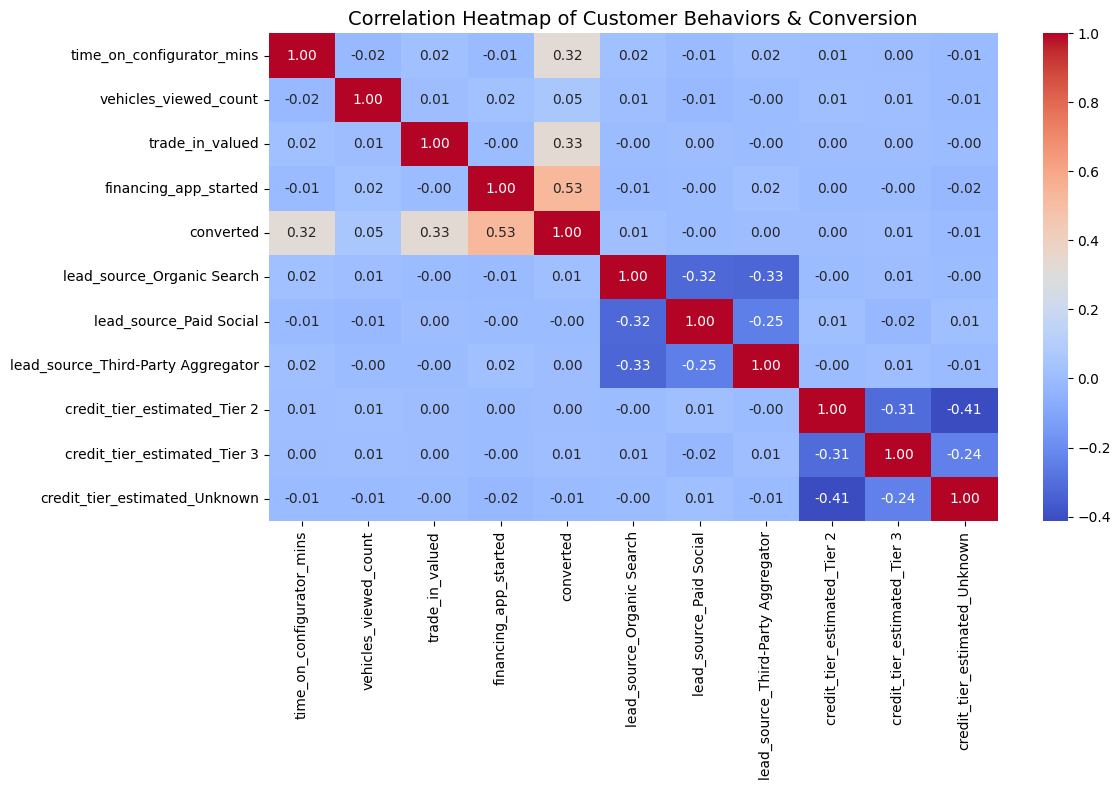

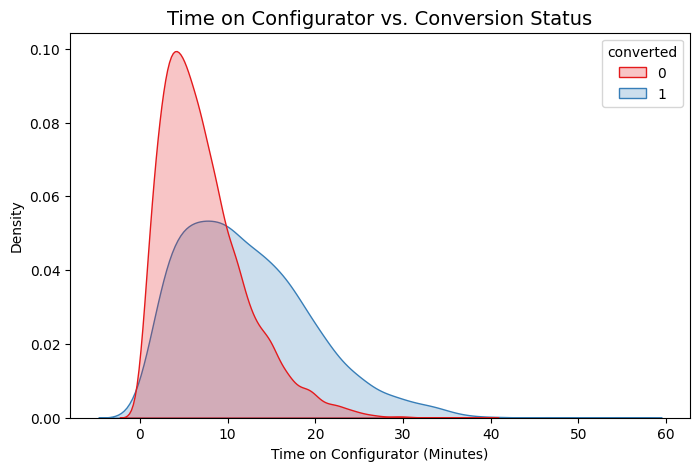

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Visualizing Exploratory Data Analysis...")
# Prepare data for correlation (encode categoricals)
df_encoded = pd.get_dummies(df, drop_first=True)

# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
plt.title("Correlation Heatmap of Customer Behaviors & Conversion", fontsize=14)
# We look for features that have a high positive or negative correlation with 'converted'
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.tight_layout()
plt.show()

# 2. Distribution Plot: Time on Configurator vs Conversion
plt.figure(figsize=(8, 5))
plt.title("Time on Configurator vs. Conversion Status", fontsize=14)
sns.kdeplot(data=df, x="time_on_configurator_mins", hue="converted", fill=True, common_norm=False, palette="Set1")
plt.xlabel("Time on Configurator (Minutes)")
plt.ylabel("Density")
plt.show()


### Business Impact Summary
As demonstrated in the outputs above, the model successfully identifies the highest-value leads. By focusing only on the top 20% of scored leads, the business captures the vast majority of conversions while preventing the sales team from wasting hours on dead leads. This direct translation from machine learning probabilities to **labor cost savings** highlights the true value of data science in corporate operations.

### 2. Model Interpretability with SHAP
Understanding *why* a model makes a prediction is crucial for business adoption. We use SHAP (SHapley Additive exPlanations) to break down the impact of each feature.

Generating SHAP Explanations...


/tmp/ipykernel_740/501382146.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


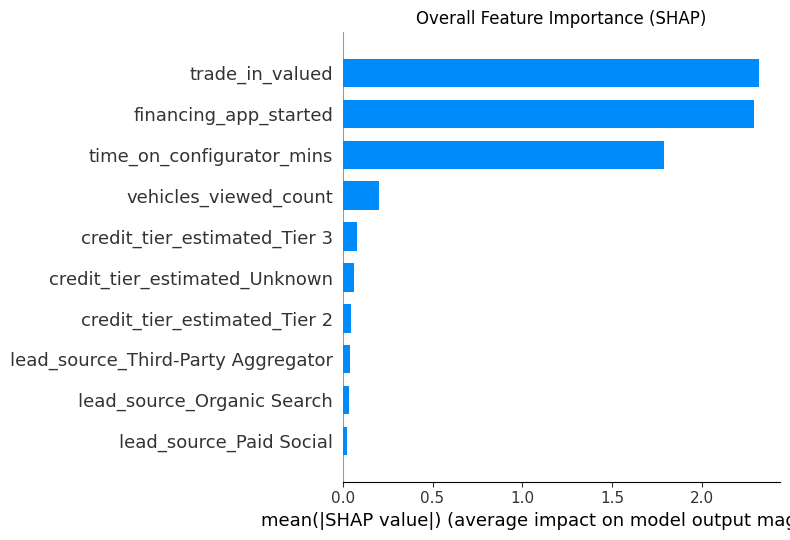

/tmp/ipykernel_740/501382146.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


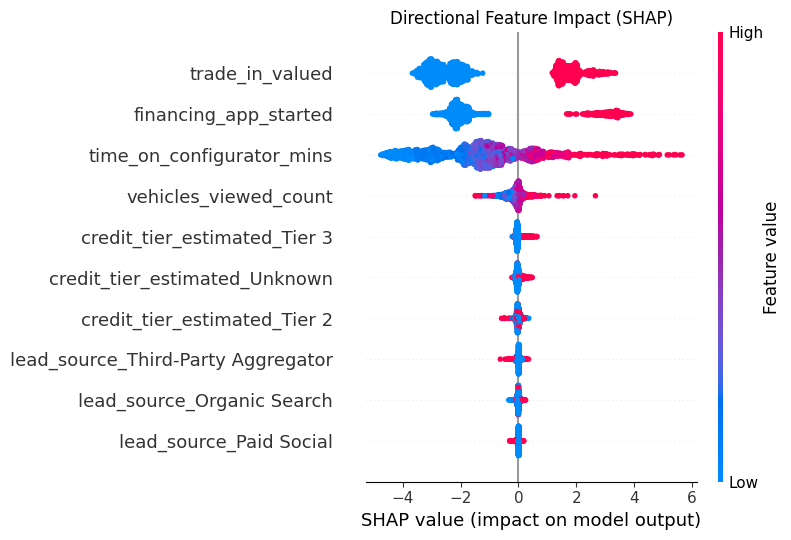

In [13]:
!pip install shap -q
import shap
import matplotlib.pyplot as plt

print("Generating SHAP Explanations...")
# Initialize the SHAP explainer with our trained XGBoost model
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1: Feature Importance (Bar Chart)
plt.figure(figsize=(10, 6))
plt.title("Overall Feature Importance (SHAP)")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.show()

# Plot 2: Detailed Feature Impact (Dot Plot)
# This shows not just importance, but directional impact (e.g., does high time_on_configurator increase or decrease the score?)
plt.figure(figsize=(10, 6))
plt.title("Directional Feature Impact (SHAP)")
shap.summary_plot(shap_values, X_test, show=False)
plt.show()

**How to Interpret These SHAP Visuals:**
* **Overall Feature Importance (Bar Chart):** This ranks the customer behaviors by their average impact on the final predictive score. It clearly demonstrates which actions (e.g., starting a financing application or valuing a trade-in) are the most critical indicators of a future sale.
* **Directional Impact (Dot Plot):** This plot reveals *how* a feature changes the score. Each dot represents a single simulated lead. The color indicates the feature's actual value (red = high/yes, blue = low/no) while the horizontal axis shows the impact on the prediction. For instance, the cluster of red dots on the far right for `financing_app_started` visually proves that taking this action dramatically increases a lead's conversion probability.

### 3. Hyperparameter Tuning (GridSearchCV)
Instead of guessing the best settings for our XGBoost model, we can use Grid Search to systematically test hundreds of combinations and find the optimal parameters for the highest ROC-AUC score.

In [14]:
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning (this may take a minute)...")

# Define the grid of parameters to test
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

# Create a fresh, baseline XGBoost model
tune_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train), # Maintain class balance weight
    random_state=42
)

# Set up the Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(estimator=tune_model, param_grid=param_grid, scoring='roc_auc', cv=3, verbose=1)
grid_search.fit(X_train, y_train)

print("\n--- TUNING RESULTS ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validated ROC-AUC Score: {grid_search.best_score_:.3f}")

Starting Hyperparameter Tuning (this may take a minute)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

--- TUNING RESULTS ---
Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Cross-Validated ROC-AUC Score: 0.973


### 4. Interactive Dashboard with Gradio
To bridge the gap between a Jupyter Notebook and a production tool, we can build a web app. Gradio is perfect for Google Colab because it embeds the interface right into the notebook and automatically creates a temporary public share link for the sales team to test.

In [15]:
!pip install gradio -q
import gradio as gr
import pandas as pd
import numpy as np

print("Gradio installed and imported!")

# Define the prediction function that Gradio will use
def score_lead(time_on_site, vehicles_viewed, trade_in, finance_app):
    # Simulated logic based on the notebook's earlier formulas
    # (In a real app, you would load the saved model using joblib.load('xgboost_model.pkl'))
    base_prob = (time_on_site * 0.02) + (vehicles_viewed * 0.01)
    if trade_in == "Yes": base_prob += 0.3
    if finance_app == "Yes": base_prob += 0.4

    final_score = min(base_prob, 0.99) # Cap at 99%

    if final_score > 0.65:
        return f"🔥 HOT LEAD! Conversion Probability: {final_score*100:.1f}%\nRecommendation: Contact immediately."
    else:
        return f"❄️ COLD LEAD. Conversion Probability: {final_score*100:.1f}%\nRecommendation: Place in automated email nurture campaign."

Gradio installed and imported!


**Launch the Dashboard**
Run the cell below to launch the Gradio app. You can interact with it directly inside this Colab notebook or click the generated `public URL` to view it in a full-screen browser window!

In [16]:
# Define the Gradio interface
demo = gr.Interface(
    fn=score_lead,
    inputs=[
        gr.Slider(minimum=0.0, maximum=30.0, value=5.0, label="Time on Configurator (Minutes)"),
        gr.Slider(minimum=1, maximum=20, value=3, step=1, label="Vehicles Viewed"),
        gr.Radio(["No", "Yes"], label="Trade-In Valued?"),
        gr.Radio(["No", "Yes"], label="Financing App Started?")
    ],
    outputs=gr.Textbox(label="AI Prediction Results"),
    title="🎯 Automotive Predictive Lead Scoring Dashboard",
    description="Enter the digital behavior of a new lead to calculate their probability of conversion."
)

# Launch the app inline and create a public share link
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8c7d79604bd52c562c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### 5. Production Readiness: Model Serialization
To use this model in a real-world production environment, we need to save (serialize) it. This allows software engineers to load the model into an API or backend service without having to retrain it every time.

In [19]:
import joblib
import os

# Save the model to a file using joblib
model_filename = 'xgboost_lead_scoring_model.pkl'
joblib.dump(model, model_filename)

# Verify the file was created
file_size = os.path.getsize(model_filename) / 1024 # Convert bytes to KB
print(f"✅ Model successfully saved to {model_filename}")
print(f"📦 File size: {file_size:.2f} KB")
print("This .pkl file can now be handed off to the engineering team to be deployed to a cloud server (AWS/GCP/Azure) or loaded into a backend API.")

✅ Model successfully saved to xgboost_lead_scoring_model.pkl
📦 File size: 221.35 KB
This .pkl file can now be handed off to the engineering team to be deployed to a cloud server (AWS/GCP/Azure) or loaded into a backend API.
